# Phase 7 · Choix et entraînement du modèle : carnet de travail

Ce carnet **relit** les résultats enregistrés par les outils de la phase 7 ; il ne recalcule rien et ne lit pas le
jeu de test. Le notebook de certification (§ 9.A à 9.D, 9.F) présente les conclusions ; ce carnet montre le détail.
Règles B1 à B5 validées et committées **avant** le premier calcul (choix méthodologiques § 7 quinquies).

In [1]:
# --- Environment: the project package and the recorded results --------------------------------
import json
import sys
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import matplotlib.pyplot as plt
import pandas as pd

from churn_saas.notebook import afficher_tableau


def resultat(nom):
    return json.loads((RACINE / "resultats" / f"{nom}.json").read_text(encoding="utf-8"))

## 1. Réglage des arbres (B3) et descriptif des modèles comparés

In [2]:
selection = resultat("selection_modele")
afficher_tableau(pd.DataFrame([{"famille": f, **r["meilleurs_parametres"], "PR-AUC de grille": r["pr_auc_grille"]}
                               for f, r in selection["reglages"].items()]), titre="Meilleurs réglages")
afficher_tableau(pd.DataFrame({n: {k: v for k, v in d.items() if k != "hyperparametres_cles"}
                               for n, d in selection.get("descriptifs", {}).items()}).T.reset_index(names="modèle"),
                 titre="Descriptif lu sur chaque modèle")

famille,modele__class_weight,modele__max_depth,modele__min_samples_leaf,modele__n_estimators,PR-AUC de grille,modele__learning_rate,modele__min_child_weight
forêt aléatoire,None,10,5,100,0.7748,NaN,NaN
xgboost,NaN,3,NaN,200,0.7794,0.05,5


modèle,famille,estimateur,calibration,copies
forêt aléatoire,foret_aleatoire,sklearn.ensemble.RandomForestClassifier,NaN,NaN
xgboost,xgboost,xgboost.sklearn.XGBClassifier,NaN,NaN
régression logistique,regression_logistique,sklearn.linear_model.LogisticRegression,NaN,NaN


## 2. Comparaison appariée à la référence figée (B1), pli par pli

modèle,PR-AUC,gain apparié,seuil (1 écart-type),plis gagnés,gain significatif
régression logistique,0.7933,0.0000,0.0188,0,False
forêt aléatoire,0.7738,-0.0195,0.0188,1,False
xgboost,0.7803,-0.0130,0.0188,1,False


pli,régression logistique,forêt aléatoire,xgboost
0,0.7809,0.7761,0.7753
1,0.8097,0.7702,0.7818
2,0.8157,0.7848,0.7928
3,0.7615,0.7483,0.7549
4,0.7965,0.7944,0.7922
5,0.8091,0.7726,0.7881
6,0.7920,0.7675,0.7825
7,0.7709,0.7730,0.7656
8,0.7790,0.7661,0.7609
9,0.8176,0.7927,0.8015


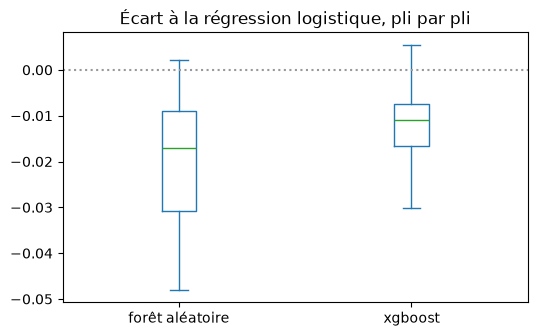

In [3]:
afficher_tableau(pd.DataFrame(selection["comparaison"]), titre="Gain apparié face à la régression logistique")
par_pli = pd.DataFrame(selection["par_pli"])
afficher_tableau(par_pli.round(4).reset_index(names="pli"), titre="PR-AUC des 25 plis")
ax = (par_pli.drop(columns="régression logistique").sub(par_pli["régression logistique"], axis=0)).plot(
    kind="box", figsize=(6, 3.5), title="Écart à la régression logistique, pli par pli")
ax.axhline(0, color="#999999", linestyle=":")
plt.show()

**Lecture.** Les deux familles d'arbres font moins bien que la régression sur presque tous les plis (écarts
négatifs) : la règle B1 retient la régression.

## 3. Calibration (B2), évaluation unique sur le test (B4), valeur client (B5)

In [4]:
afficher_tableau(pd.DataFrame(selection["calibration"]["methodes"]).T.reset_index(names="méthode"),
                 titre="Calibration dans les plis")
evaluation = resultat("evaluation_finale")
afficher_tableau(pd.DataFrame({"valeur": evaluation["metriques"], "intervalle à 95 %": evaluation["intervalles_95"]})
                 .reset_index(names="métrique"), titre=f"Évaluation unique sur le test ({evaluation['date']})")
valeur = resultat("modele_valeur_vie")
afficher_tableau(pd.DataFrame(valeur["r2_log_par_pli"]).round(4).reset_index(names="pli"),
                 titre=f"Valeur client — retenu : {valeur['modele_retenu']}")

méthode,PR-AUC,erreur de calibration,erreur hors pli (première répétition)
sigmoid,0.7934,0.0298,0.0097
isotonic,0.7901,0.0318,0.0124


métrique,valeur,intervalle à 95 %
PR-AUC,0.7612,"[0.7118, 0.8059]"
ROC-AUC,0.8815,"[0.858, 0.9045]"
rappel haut,0.3143,"[0.2842, 0.3514]"
précision haut,0.8800,"[0.81, 0.94]"
Brier,0.1206,"[0.1075, 0.1327]"
erreur de calibration,0.0364,"[0.0282, 0.061]"


pli,régression linéaire,forêt de régression
0,0.8085,0.8835
1,0.8068,0.8953
2,0.8016,0.8933
3,0.8063,0.8772
4,0.8000,0.8900


## Journal de bord
- B1 : la régression logistique gagne sur 24 plis sur 25 ; B2 : calibration sigmoïde (0,030) ; B4 : le test lu une
  seule fois (PR-AUC 0,761) ; B5 : forêt de régression pour la valeur client (R² 0,888 contre 0,805).
- Le descriptif de chaque modèle est lu sur l'objet (`decrire_modele`), pas saisi.